# 16 · Filing delay: how long companies take to report

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/16_filing_delay.ipynb)

**What you will learn**

- How to measure the reporting lag: days from the end of a fiscal period to the SEC filing.
- Who files late against their own history, a classic warning sign.
- Why the acceptance timestamp, not the filing date, decides when you can trade on a filing.

**Plan required:** none (free sample tier).

In [1]:
%pip install -q valuein-sdk matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. The lag

`filing.report_date` is the end of the period the report covers; `filing_date` is the day the
SEC received it. SEC deadlines for the largest companies (large accelerated filers) are 60 days
after year end for a 10-K and 40 days after quarter end for a 10-Q; smaller filers get longer.
Companies that suddenly take longer than usual are often dealing with an accounting problem,
an auditor issue or a restatement.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from valuein_sdk import ValueinClient

client = ValueinClient()

filings = client.run_query("""
    SELECT f.entity_id AS cik, r.symbol AS ticker, r.sector, f.form_type, f.report_date,
           f.filing_date, f.accepted_at,
           date_diff('day', f.report_date, f.filing_date) AS lag_days
    FROM filing f
    JOIN (SELECT cik, any_value(symbol) AS symbol, any_value(sector) AS sector
          FROM "references" WHERE is_primary_ticker GROUP BY cik) r ON r.cik = f.entity_id
    WHERE f.form_type IN ('10-K', '10-Q') AND NOT f.is_amendment
      AND f.report_date >= DATE '2021-01-01'
""")
print(len(filings), "original 10-K and 10-Q filings")
filings.groupby("form_type")["lag_days"].describe(percentiles=[0.1, 0.5, 0.9]).round(1)


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


14432 original 10-K and 10-Q filings


,count,mean,std,min,10%,50%,90%,max
form_type,,,,,,,,
10-K,3379.0,50.0,10.7,18.0,38.0,51.0,59.0,286.0
10-Q,11053.0,32.1,8.2,8.0,24.0,33.0,39.0,363.0


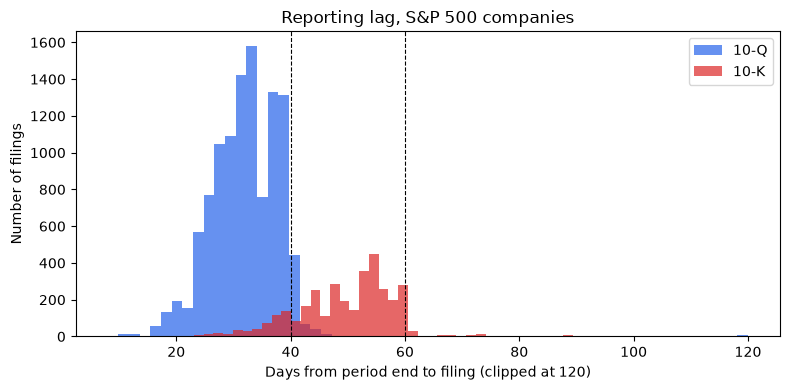

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for form, color in [("10-Q", "#2563eb"), ("10-K", "#dc2626")]:
    ax.hist(filings.loc[filings["form_type"] == form, "lag_days"].clip(0, 120), bins=60,
            alpha=0.7, label=form, color=color)
for deadline in (40, 60):
    ax.axvline(deadline, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Days from period end to filing (clipped at 120)")
ax.set_ylabel("Number of filings")
ax.set_title("Reporting lag, S&P 500 companies")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Late against their own history

A fixed threshold mostly flags smaller filers, which have later deadlines. A sharper signal
compares each filing with the same company's usual lag for the same form.

In [4]:
filings = filings.sort_values("filing_date")
usual = filings.groupby(["cik", "form_type"])["lag_days"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=2).median())
filings["days_later_than_usual"] = filings["lag_days"] - usual
late = filings[filings["days_later_than_usual"] >= 15]
print(f"{len(late)} filings came 15 or more days later than the company's recent median")
late.sort_values("days_later_than_usual", ascending=False)[
    ["ticker", "form_type", "report_date", "filing_date", "lag_days", "days_later_than_usual"]
].head(10)

48 filings came 15 or more days later than the company's recent median


,ticker,form_type,report_date,filing_date,lag_days,days_later_than_usual
12332,TUP,10-Q,2023-04-01,2024-03-29,363,323.0
479,TRMB,10-Q,2024-03-29,2025-01-16,293,258.0
12333,TUP,10-Q,2023-07-01,2024-03-29,272,232.0
5069,CBB,10-Q,2021-09-30,2022-05-13,225,199.0
671,XRAY,10-Q,2022-03-31,2022-11-07,221,185.0
3131,SMCI,10-K,2024-06-30,2025-02-25,240,181.0
480,TRMB,10-Q,2024-06-28,2025-01-16,202,129.0
3132,SMCI,10-Q,2024-09-30,2025-02-25,148,113.5
10368,CTLT,10-K,2023-06-30,2023-12-08,161,100.5
672,XRAY,10-Q,2022-06-30,2022-11-07,130,94.0


The `filing_delay_screener` template returns the longest raw delays in a date range, if you want
a quick list without the history comparison:

In [5]:
client.run_template("filing_delay_screener", start_date="2025-01-01", end_date="2025-12-31").head()

,ticker,form_type,report_date,filing_date,reporting_delay_days
0,TRMB,10-Q,2024-03-29,2025-01-16,293
1,SMCI,10-K,2024-06-30,2025-02-25,240
2,SMCIP,10-K,2024-06-30,2025-02-25,240
3,TRMB,10-Q,2024-06-28,2025-01-16,202
4,SMCIP,10-Q,2024-09-30,2025-02-25,148


## 3. Acceptance time decides when you can trade

The SEC accepts filings until 10 p.m. Eastern. A 10-K accepted at 5 p.m. carries that day's
`filing_date`, but the market had already closed: the earliest price that can react is the next
day's. A backtest that trades at the close of `filing_date` uses information before it was
public. Valuein's point-in-time filter uses `accepted_at`, the exact timestamp.

In [6]:
eastern = pd.to_datetime(filings["accepted_at"], utc=True).dt.tz_convert("America/New_York")
after_close = (eastern.dt.hour * 60 + eastern.dt.minute) >= 16 * 60
by_form = filings.assign(after_close=after_close).groupby("form_type")["after_close"].mean()
by_form.map("{:.0%}".format).rename("accepted after the 4 p.m. close")

form_type
10-K    64%
10-Q    61%
Name: accepted after the 4 p.m. close, dtype: str

A large share of reports arrive after the close. For daily backtests, fill no earlier than the
first close after `accepted_at`: `client.forward_returns(..., execution_lag=1)` does this by
default on Pro and Institutional.

In [7]:
client.close()

## Next steps

- Back to the start of the learning path: [`examples/README.md`](../README.md).
- Combine filing delay with the restatement feed (notebook 06): late filers and restaters
  overlap.